In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

#Scikit-Learn tools for NLP & ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('customer_churn_nlp.csv')

print(f"Dataset shape : {df.shape[0]} rows, {df.shape[1]} columns")
print(f"First 5 Customer Profiles: ")
df.head()

Dataset shape : 500 rows, 7 columns
First 5 Customer Profiles: 


,CustomerID,Tenure,MonthlyCharges,SupportTickets,Contract,CustomerFeedback,Churn
0,CUST-1000,40,35.09,0,One year,Customer support was very helpful and polite.,0
1,CUST-1001,22,50.26,0,One year,Smooth connection and fair monthly prices.,0
2,CUST-1002,13,64.71,1,Month-to-month,Excellent coverage and fast streaming experience.,0
3,CUST-1003,23,58.64,0,One year,"Great service, very happy with internet speed!",0
4,CUST-1004,53,27.57,2,One year,Easy billing process and fast resolution.,0


C:\Users\mrnam\AppData\Local\Temp\ipykernel_25588\1645519098.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Churn',palette=['red','green'],ax=axes[0])
C:\Users\mrnam\AppData\Local\Temp\ipykernel_25588\1645519098.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Retained (0)','Churned (1)'])


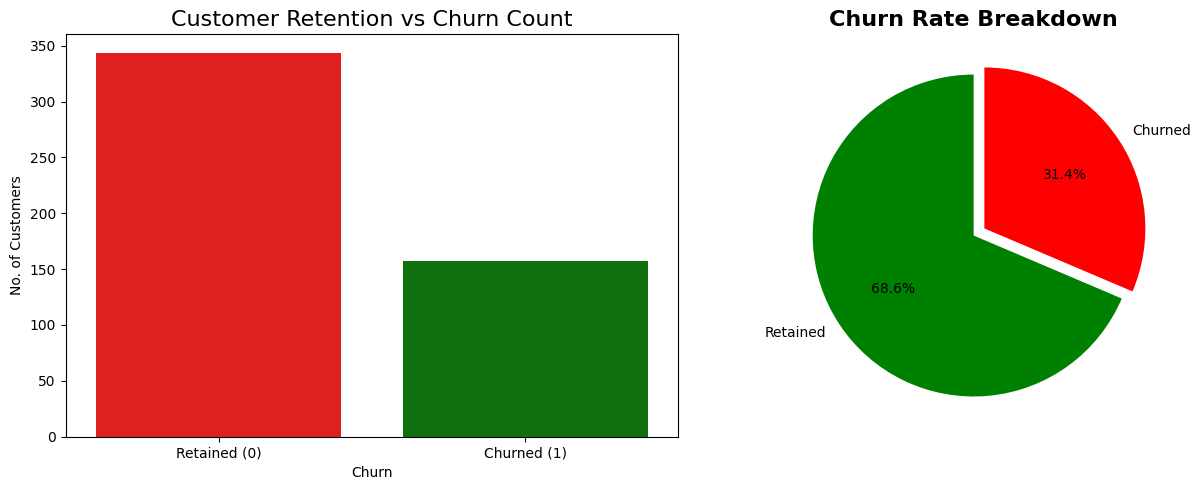

In [11]:
churn_counts=df['Churn'].value_counts()

fig,axes=plt.subplots(1,2,figsize=(13,5))
sns.countplot(data=df,x='Churn',palette=['red','green'],ax=axes[0])
axes[0].set_title('Customer Retention vs Churn Count',fontsize=16)
axes[0].set_xticklabels(['Retained (0)','Churned (1)'])
axes[0].set_ylabel('No. of Customers')

axes[1].pie(churn_counts,labels=['Retained','Churned'],autopct='%1.1f%%',colors=['green','red'],startangle=90,explode=(0,0.08))
axes[1].set_title('Churn Rate Breakdown',fontsize=16,fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\mrnam\AppData\Local\Temp\ipykernel_25588\1550741275.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Churn',y='Tenure',palette=['red','green'])


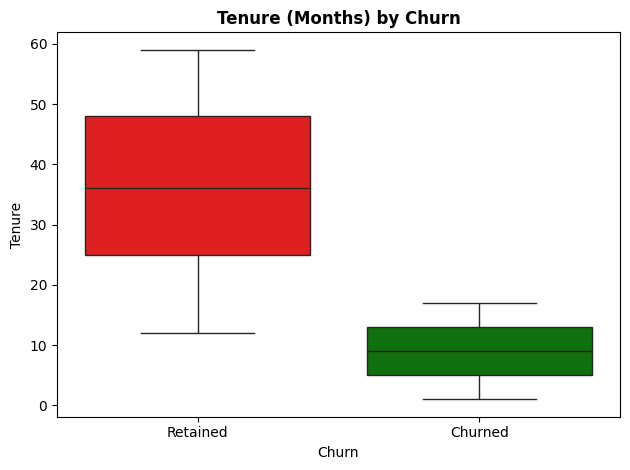

In [12]:
#Tenure vs Churn
sns.boxplot(data=df,x='Churn',y='Tenure',palette=['red','green'])
plt.title('Tenure (Months) by Churn',fontweight='bold')
plt.xticks([0,1],['Retained','Churned'])
plt.tight_layout()
plt.show()

C:\Users\mrnam\AppData\Local\Temp\ipykernel_25588\2069631048.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Churn',y='MonthlyCharges',palette=['red','green'])


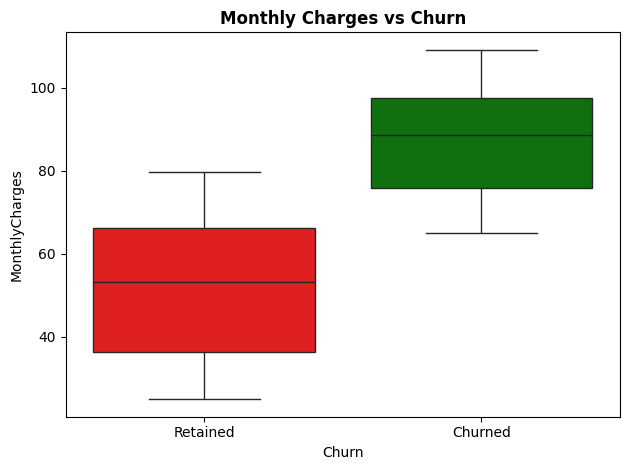

In [13]:
#Monthly Charges vs Churn
sns.boxplot(data=df,x='Churn',y='MonthlyCharges',palette=['red','green'])
plt.title('Monthly Charges vs Churn',fontweight='bold')
plt.xticks([0,1],['Retained','Churned'])
plt.tight_layout()
plt.show()

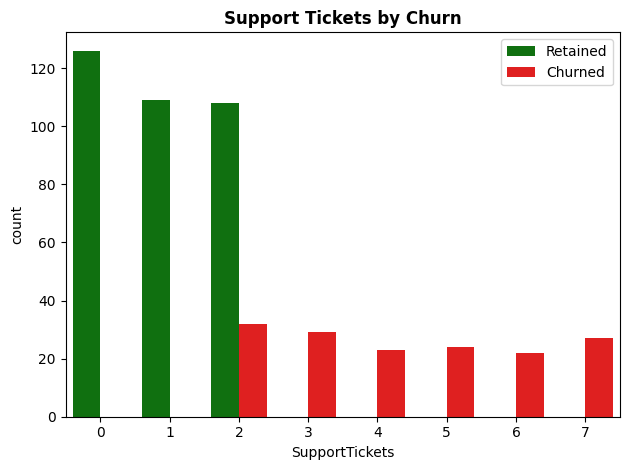

In [14]:
#Support Tickets vs Churn
sns.countplot(data=df,x='SupportTickets',hue='Churn',palette=['green','red'])
plt.title('Support Tickets by Churn',fontweight='bold')
plt.legend(['Retained','Churned'])
plt.tight_layout()
plt.show()

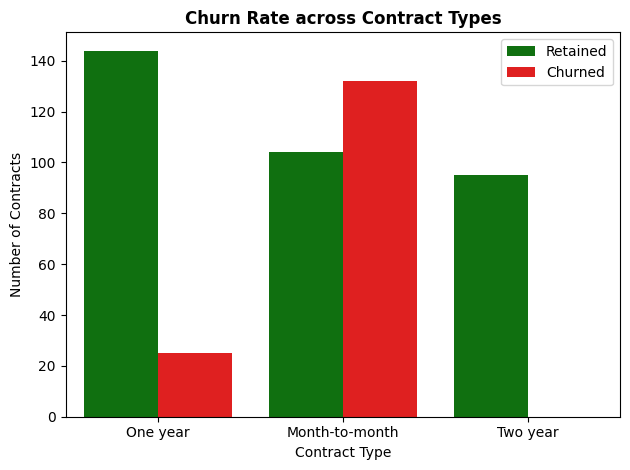

In [16]:
#Contract Type vs Churn
sns.countplot(data=df,x='Contract',hue='Churn',palette=['green','red'])
plt.title('Churn Rate across Contract Types',fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Contracts')
plt.legend(['Retained','Churned'])
plt.tight_layout()
plt.show()

In [18]:
#NLP Behaviour Analysis
print("--- Sample Feedback from Retained Customers ---")
for text in df[df['Churn']==0]['CustomerFeedback'].head(3):
    print(f"[Retained]: {text}")

print("\n--- Sample Feedback from Churned Customers ---")
for text in df[df['Churn']==1]['CustomerFeedback'].head(3):
    print(f"[Churned]: {text}")

--- Sample Feedback from Retained Customers ---
[Retained]: Customer support was very helpful and polite.
[Retained]: Smooth connection and fair monthly prices.
[Retained]: Excellent coverage and fast streaming experience.

--- Sample Feedback from Churned Customers ---
[Churned]: Bad experience, moving to another provider soon.
[Churned]: Cancel my subscription, worst customer care ever.
[Churned]: Monthly charges are way too expensive for bad service.


In [ ]:
# 1. Encode Categorical Variable ('Contract)
df_contract_encoded=pd.get_dummies(df[['Contract']],drop_first=True,dtype=int)

# 2. Extract TF-IDF Features from Customer Feedback (15 top features for simplicity)
tfidf_vectorizer=TfidfVectorizer(max_features=15,stop_words='english',ngram_range=(1,2))
text_features=tfidf_vectorizer.fit_transform(df['CustomerFeedback']).toarray()

#Convert text features to DataFrame with clear column names
text_feature_names=[f"text_{word}" for word in tfidf_vectorizer.get_feature_names_out()]
df_text_encoded=pd.DataFrame(text_features,columns=text_feature_names)
print(df_text_encoded)
# 3. Select Numerical Features
df_numeric=df[['Tenure','MonthlyCharges','SupportTickets']]

# 4. Combine (Fuse) Numerical, Categorical and NLP text features
x=pd.concat([df_numeric,df_contract_encoded,df_text_encoded],axis=1)
y=df['Churn']

print(f"Combined Feature Matrix X Shape: {x.shape[0]} samples, {x.shape[1]} features")
print("Feature Column List: ")
print(list(x.columns))

     text_care  text_connection  text_customer  text_customer care  \
0          0.0         0.000000            1.0                 0.0   
1          0.0         0.710409            0.0                 0.0   
2          0.0         0.000000            0.0                 0.0   
3          0.0         0.000000            0.0                 0.0   
4          0.0         0.000000            0.0                 0.0   
..         ...              ...            ...                 ...   
495        0.0         0.000000            0.0                 0.0   
496        0.0         0.000000            0.0                 0.0   
497        0.0         0.000000            0.0                 0.0   
498        0.0         1.000000            0.0                 0.0   
499        0.0         0.000000            0.0                 0.0   

     text_excellent  text_excellent coverage  text_experience  text_fast  \
0          0.000000                 0.000000         0.000000   0.000000   
1      

In [29]:
#Split dataset 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

print(f"Target set size: {x_train.shape[0]} samples")
print(f"Testing set size: {x_test.shape[0]} samples")

#Model 1: Logistic Regression
model_lr=LogisticRegression(max_iter=1000,random_state=42)
model_lr.fit(x_train,y_train)
y_pred_lr=model_lr.predict(x_test)
acc_lr=accuracy_score(y_test,y_pred_lr)
print(f"Logistic Regression Accuracy Score: {acc_lr:.2%}")

#Model 2: Random Forest 
model_rf=RandomForestClassifier(n_estimators=100,random_state=42)
model_rf.fit(x_train,y_train)
y_pred_rf=model_rf.predict(x_test)
acc_rf=accuracy_score(y_test,y_pred_rf)
print(f"Random Forest Accuracy Score: {acc_rf:.2%}")

Target set size: 400 samples
Testing set size: 100 samples
Logistic Regression Accuracy Score: 100.00%
Random Forest Accuracy Score: 100.00%
